# Lab 3: RNNs and Transformers for epidemic prediction

### Created by Wei Jin and Zewen Liu

Please feel free to reach out with questions or suggestions: wei.jin@emory.edu and zewen.liu@emory.edu

## Part 1: Recurrent Neural Networks (RNN)


### Theory

Recurrent Neural Networks (RNNs) are a class of neural networks specifically designed to handle sequential data by maintaining a hidden state that captures temporal dependencies among sequence elements. This capability makes them particularly suitable for applications like epidemic prediction, where modeling the dynamics of disease spread over time is crucial.

**Key Concepts in RNNs:**
- **Hidden State:** RNNs maintain a hidden state that encapsulates information learned from previous time steps.
- **Weight Sharing:** The same weights are applied across all time steps, significantly reducing the number of parameters.
- **Backpropagation Through Time (BPTT):** This is the process used to train RNNs, where gradients are propagated backward through each time step.

**Mathematical Representation:**
$$
h_t = \text{tanh}(W_{hh} h_{t-1} + W_{xh} x_t + b_h)
$$
$$
y_t = W_{hy} h_t + b_y
$$
Where:
- $h_t$ is the hidden state at time $t$,
- $x_t$ is the input at time $t$,
- $W_{hh}$, $W_{xh}$, $ W_{hy}$ are the weights,
- $b_h$, $b_y$ are the biases.


<img src="https://drive.google.com/uc?id=12pVW058VrBAuvMpSWmLTn_pa7bel2twh" alt="RNN Diagram" width="800"/>


### RNN Example

In [1]:
import torch
import torch.nn as nn

# Define a simple RNN class
class BasicRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(BasicRNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)  # RNN layer
        self.fc = nn.Linear(hidden_size, output_size)  # Linear layer to get the output

    def forward(self, x):
        # Forward pass through RNN layer
        out, hidden = self.rnn(x)
        # We take the output from the last timestep
        out = self.fc(out[:, -1, :])
        return out

# Sample input data (e.g., a batch of 1 sequence with 10 timesteps, each timestep has 3 features)
input_data = torch.randn(1, 10, 3)  # (batch_size, sequence_length, features)

# Instantiate the RNN model
rnn_model = BasicRNN(input_size=3, hidden_size=5, output_size=2)

# Forward pass through the model
output = rnn_model(input_data)

# Print the input, hidden state and final output
print("Input Data:")
print(input_data)

print("\nOutput from RNN Model:")
print(output)

Input Data:
tensor([[[ 1.3057, -0.3432,  0.9524],
         [-0.3772,  0.8987, -0.2670],
         [-1.2472,  1.5878, -0.6296],
         [ 1.4754,  0.9596,  1.1353],
         [ 0.3419, -0.8127, -0.7877],
         [ 0.2441,  0.6275,  0.7070],
         [ 1.2089,  1.8094,  0.1724],
         [ 0.3799, -1.3441, -0.0857],
         [ 0.3408, -0.2488, -0.2655],
         [ 0.4556, -0.4516, -0.7123]]])

Output from RNN Model:
tensor([[-0.1325, -0.3525]], grad_fn=<AddmmBackward0>)


## Part 2: Transformer

### Theory

Transformers are a type of neural network architecture that have revolutionized sequence modeling tasks. Unlike RNNs, GRUs, and LSTMs, which process data sequentially, Transformers use a mechanism called **self-attention** to weigh the importance of different parts of the input sequence, regardless of their position. This allows Transformers to capture long-range dependencies more effectively and process sequences in parallel.

**Key Concepts in Transformers:**
- **Self-Attention:** Allows the model to weigh the importance of different input tokens when processing a specific token.
- **Multi-Head Attention:** Runs the attention mechanism multiple times in parallel, allowing the model to jointly attend to information from different representation subspaces at different positions.
- **Positional Encoding:** Since Transformers do not process sequences sequentially, positional encodings are added to the input embeddings to provide the model with information about the position of each token in the sequence.
- **Feed-Forward Networks:** Each attention sub-layer is followed by a simple, fully connected feed-forward network.

**Mathematical Representation (Self-Attention):**
$$
\text{Attention}(Q, K, V) = \text{softmax}(\frac{QK^T}{\sqrt{d_k}})V
$$
Where:
- $Q$, $K$, and $V$ are the Query, Key, and Value matrices, respectively.
- $d_k$ is the dimension of the key vectors.

![Transformer Diagram](https://drive.google.com/uc?id=1JtM3D5K5z98u6k6g1v8q1Z3zZ1v8q1Z3)

In [2]:
!pip install torchtext

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 21.9 MB/s eta 0:00:0000:010:01


In [3]:
import torch
import torch.nn as nn
import math

# Self-defined Positional Encoding
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Create a long enough positional encoding matrix
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)  # even indices
        pe[:, 1::2] = torch.cos(position * div_term)  # odd indices
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)

        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (batch_size, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

# Updated TransformerModel using the custom PositionalEncoding
class TransformerModel(nn.Module):
    def __init__(self, input_size, d_model, nhead, num_encoder_layers, lookback, output_size, dropout=0.1, max_len=5000):
        super(TransformerModel, self).__init__()
        self.model_type = 'Transformer'
        self.src_mask = None

        self.linear_in = nn.Linear(input_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model, dropout=dropout, max_len=max_len)

        self.encoder_layer = nn.TransformerEncoderLayer(d_model, nhead, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(self.encoder_layer, num_encoder_layers)

        self.linear_out = nn.Linear(d_model, output_size)
        self.d_model = d_model

        self.init_weights()

    def init_weights(self):
        initrange = 0.1
        self.linear_in.bias.data.zero_()
        self.linear_in.weight.data.uniform_(-initrange, initrange)
        self.linear_out.bias.data.zero_()
        self.linear_out.weight.data.uniform_(-initrange, initrange)

    def forward(self, src):
        src = self.linear_in(src) * math.sqrt(self.d_model)
        src = self.pos_encoder(src)
        output = self.transformer_encoder(src, self.src_mask)
        output = output[:, -1, :]
        output = self.linear_out(output)
        return output

# Example usage
input_data = torch.randn(1, 10, 3)
transformer_model = TransformerModel(input_size=3, d_model=128, nhead=4, num_encoder_layers=2, lookback=10, output_size=2)
output = transformer_model(input_data)

print("Input Data:")
print(input_data)
print("Model's Output:")
print(output)

Input Data:
tensor([[[ 0.8717, -1.5132,  0.8255],
         [ 0.5998,  2.2870, -0.6289],
         [-0.2672, -0.6131,  1.8505],
         [ 0.0738,  0.3444,  0.9575],
         [-1.6687, -0.6775,  1.0135],
         [-0.1965, -0.7898, -0.7338],
         [ 1.0139,  0.7141,  0.0932],
         [ 1.0810, -0.6574, -0.7767],
         [ 1.8324,  1.0101, -1.4934],
         [-0.2059, -0.4498, -0.4431]]])
Model's Output:
tensor([[-0.2934,  0.4671]], grad_fn=<AddmmBackward0>)


## Part 4: Predicting future infections with Measle dataset

### 0. import packages

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
import urllib.request

# global configs
lookback = 16
horizon = 1
batch_size = 32
learning_rate = 1e-3
num_epochs = 120


### 1. Load time series data

In [5]:
url_data = "https://drive.google.com/uc?export=download&id=12WpPH-FwJ5Os11IGKLkzVgENglQbu37a"
urllib.request.urlretrieve(url_data, 'measles.pt')

raw_data = torch.load('measles.pt', weights_only=False)
weekly_infection = raw_data['weekly_infection']
data = torch.FloatTensor(np.array(weekly_infection)).T

In [6]:
weekly_infection

,Abingdon,Abram,Accrington,Acton,Adlington,Adwick.le.Street,Aldeburgh,Alderley.Edge,Aldershot,Aldridge,...,Rhymney,Risca,Ruthin,Swansea,Tenby,Towyn,Tredegar,Usk,Welshpool,Wrexham
rownames,,,,,,,,,,,,,,,,,,,,,
44.01923,0,0,0,0,0,0,0,0,0,2,...,0,0,0,0,0,0,1,0,0,0
44.03846,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
44.05769,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
44.07692,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,2,0,0,0
44.09615,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,6,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65.15385,19,0,7,49,0,0,0,3,39,31,...,0,1,2,7,0,0,0,0,0,4
65.17308,37,0,7,42,0,0,0,0,45,23,...,0,0,2,29,0,0,0,0,0,7
65.19231,39,1,12,49,0,0,0,0,18,9,...,0,3,1,11,0,0,0,0,0,1


In [7]:
url_data = "https://drive.google.com/uc?export=download&id=13gHDO6Rh5gZwqo8MLDyyiLtPCd9gD0nD"
urllib.request.urlretrieve(url_data, 'aggregated_tycho_v1.0.0.pt')
tycho_data = torch.load('aggregated_tycho_v1.0.0.pt')
print("Diseases:", list(tycho_data.keys()))

# We pick Mumps as an example
data2 = tycho_data['DIPHTHERIA'].unsqueeze(1).float()
print('length: ', data.shape[0])

Diseases: ['DIPHTHERIA', 'HEPATITIS A', 'MEASLES', 'MUMPS', 'SMALLPOX']
length:  946


### 2. Data preprocessing

In [8]:
# This class is used to perform normalization and store the mean and variance of the input samples, which can later be denormalized
class normalization():
    def __init__(self, eps=1e-5) -> None:
        self.eps = eps
        self.mean = None
        self.std = None

    # Get the mean and standard variance of the inputs
    def _get_statistics(self, x):
        dim2reduce = tuple(range(1, x.ndim-1))
        self.mean = torch.mean(x, dim=dim2reduce, keepdim=True).detach()
        self.stdev = torch.sqrt(torch.var(x, dim=dim2reduce, keepdim=True, unbiased=False) + self.eps).detach()

    # Perform normalization
    def norm(self, x):
        self._get_statistics(x)
        x = x - self.mean
        x = x / self.stdev
        return x

    # Perform denormalization
    def denorm(self, x):
        x = x * self.stdev
        x = x + self.mean
        return x

# initialize normalization class
normalize = normalization()

In [9]:
# define a class for the measle dataset
class measle_dataset(Dataset):
    def __init__(self, data, lookback, horizon):
        self.full_data = data
        self.num_time_steps = data.shape[0]
        self.lookback = lookback
        self.horizon = horizon
        self.data = self.split(self.full_data, self.lookback, self.horizon)

    # Cut the original sequence using a slide window: L->Nx(looback+horizon)
    def split(self, data, lookback, horizon):
        tmp = []
        for i in range(len(data) - lookback - horizon):
            history = data[i : i+self.lookback]
            future = data[i+lookback : i+lookback+horizon]
            tmp.append((history, future))
        return tmp

    def __len__(self):
        return len(self.data)

    # defines how to output data in DataLoader (Pytorch DataLoader receives the output of this function and then output the batched data)
    def __getitem__(self, index):
        history_data, label = self.data[index]
        return history_data, label


In [10]:
# Get measle data for one city: e.g. London
city_index = 441
single_region_data = data[city_index,:]
print("total time steps: ", len(single_region_data))
print(single_region_data)

total time steps:  1108
tensor([  82.,   98.,  118.,  ..., 1444., 1540., 1089.])


In [11]:
# split data into training and testing set (For real-time forecasting, the period of training set should be earlier than the testing set)
# length of data
total_steps = len(single_region_data)
# proportion of training sample
train_rate = 0.4
train_steps = int(total_steps*train_rate)

# get training and testing split
train_data = single_region_data[:train_steps]
test_data = single_region_data[train_steps:]


# Load the data using the predifined measle_dataset class
train_dataset = measle_dataset(train_data, lookback, horizon)
test_dataset = measle_dataset(test_data, lookback, horizon)

# Load the measle datasets into pytorch DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

### 3. Training and Testing Functions

In [12]:
# training function
def train(model, epochs):
    # Initialize loss function. Here we use Mean Square Error
    criterion = nn.MSELoss()
    # Initailize optimizer
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    # save the average loss for every epoch
    history_loss = []
    # start training
    for epoch in range(epochs):
        avg_loss = 0 # average loss in one epoch
        counter = 0 # save the number of samples
        for inputs, labels in train_loader:
            # normalize the inputs
            norm_inputs = normalize.norm(inputs.cpu())
            # clear the saved gradient in the optimizer
            optimizer.zero_grad()
            # forward function
            outputs = model(norm_inputs.unsqueeze(-1))
            # denormalize the outputs of the model
            predictions = normalize.denorm(outputs)
            # compare with the ground truth and get current MSE loss
            loss = criterion(predictions, labels.cpu())
            # back propogate the lossl; compute gradient for each variable
            loss.backward()
            # update the variables according to the gradients
            optimizer.step()
            # sum up the samples; inputs.shape[0] is the batch size
            counter += inputs.shape[0]
            # compute average loss
            avg_loss += loss.item()

        # save average loss of the current epoch
        avg_loss /= counter
        history_loss.append(avg_loss)
        # print loss
        if epoch%10==0:
            print(f'Epoch [{epoch + 1}/{epochs}], Loss: {avg_loss}')

    # plot the loss curve
    plt.figure()
    plt.plot(history_loss)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')

    return model

# testing function
def test(model, loader, criterion):
    # save groundtruth and predictions
    predictions = torch.FloatTensor()
    groundtruth = torch.FloatTensor()
    # during inference, we don't need gradients to update parameters (saving memory)
    with torch.no_grad():
        avg_loss = 0
        counter = 0
        for inputs, labels in loader:
            norm_inputs = normalize.norm(inputs)
            outputs = model(norm_inputs.unsqueeze(-1).cpu())
            preds = normalize.denorm(outputs.detach().cpu())
            loss = criterion(preds, labels)

            groundtruth = torch.cat([groundtruth, labels])
            predictions = torch.cat([predictions, preds])
            counter += inputs.shape[0]
            avg_loss += loss.item()

        avg_loss /= counter

        print(f'Evaluation: {avg_loss}')
    return predictions, groundtruth

# plotting

def plot(model, loader):
    # save groundtruth and predictions
    predictions = torch.FloatTensor()
    groundtruth = torch.FloatTensor()

    with torch.no_grad():
        data = loader.dataset.full_data
        for i in range(0, len(data)-horizon-lookback, horizon):
            history = torch.FloatTensor(data[i:i+lookback])
            label = data[i+lookback:i+lookback+horizon]

            inputs = normalize.norm(history.unsqueeze(0))
            output = model(inputs.unsqueeze(-1).cpu())
            preds = normalize.denorm(output.detach().cpu())

            groundtruth = torch.cat([groundtruth, label])
            predictions = torch.cat([predictions, preds.squeeze(0)])

    plt.figure()
    plt.plot(predictions, label='prediction')
    plt.plot(groundtruth, label='groundtruth')
    plt.xlabel('week')
    plt.ylabel('infections')
    plt.legend()
    plt.show()

    return predictions, groundtruth


### 3. Building Models

In [13]:
# RNN (for single channel data, the input_size is 1; the current data size is batch*lookback*1)
rnn_model = BasicRNN(input_size=1, hidden_size=16, output_size=horizon).cpu()
# Transformer
transformer_model = TransformerModel(input_size=1, d_model=16, nhead=2, num_encoder_layers=1, lookback=lookback, output_size=horizon, dropout=0).cpu()


In [14]:
rnn_model

BasicRNN(
  (rnn): RNN(1, 16, batch_first=True)
  (fc): Linear(in_features=16, out_features=1, bias=True)
)

In [15]:
transformer_model

TransformerModel(
  (linear_in): Linear(in_features=1, out_features=16, bias=True)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0, inplace=False)
  )
  (encoder_layer): TransformerEncoderLayer(
    (self_attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=16, out_features=16, bias=True)
    )
    (linear1): Linear(in_features=16, out_features=2048, bias=True)
    (dropout): Dropout(p=0, inplace=False)
    (linear2): Linear(in_features=2048, out_features=16, bias=True)
    (norm1): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
    (norm2): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
    (dropout1): Dropout(p=0, inplace=False)
    (dropout2): Dropout(p=0, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=16, out_features=16, bias=True)
   

In [17]:
single_region_data

tensor([  82.,   98.,  118.,  ..., 1444., 1540., 1089.])

## 4. Training and Evaluation

### Task:
1. Complete the following code. (relavant code is available in [lab3](https://colab.research.google.com/drive/13Rpxhg-jH8rT1zPy3_kvVaTcInkvqKeX))
2. Try and tuning the above models.

Epoch [1/500], Loss: 7544.641820486722
Epoch [11/500], Loss: 1986.1998207916117
Epoch [21/500], Loss: 1126.4440981009757
Epoch [31/500], Loss: 904.5823179433044
Epoch [41/500], Loss: 739.0376478025051
Epoch [51/500], Loss: 624.2707763098775
Epoch [61/500], Loss: 562.2698455953822
Epoch [71/500], Loss: 519.2139873952373
Epoch [81/500], Loss: 481.6028814897851
Epoch [91/500], Loss: 451.6545781238538
Epoch [101/500], Loss: 434.0483381244498
Epoch [111/500], Loss: 421.5852782916575
Epoch [121/500], Loss: 411.6849325117371
Epoch [131/500], Loss: 403.3931318829317
Epoch [141/500], Loss: 396.48713218438235
Epoch [151/500], Loss: 393.67411180952905
Epoch [161/500], Loss: 385.70439312715484
Epoch [171/500], Loss: 381.67906568643633
Epoch [181/500], Loss: 376.1605233205876
Epoch [191/500], Loss: 371.147539022383
Epoch [201/500], Loss: 366.0847215249505
Epoch [211/500], Loss: 361.00017880721833
Epoch [221/500], Loss: 356.1909169658249
Epoch [231/500], Loss: 352.7359652093878
Epoch [241/500], Loss

TransformerModel(
  (linear_in): Linear(in_features=1, out_features=16, bias=True)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0, inplace=False)
  )
  (encoder_layer): TransformerEncoderLayer(
    (self_attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=16, out_features=16, bias=True)
    )
    (linear1): Linear(in_features=16, out_features=2048, bias=True)
    (dropout): Dropout(p=0, inplace=False)
    (linear2): Linear(in_features=2048, out_features=16, bias=True)
    (norm1): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
    (norm2): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
    (dropout1): Dropout(p=0, inplace=False)
    (dropout2): Dropout(p=0, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=16, out_features=16, bias=True)
   

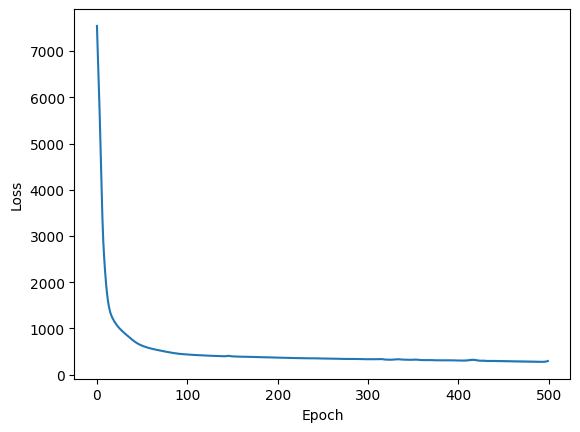

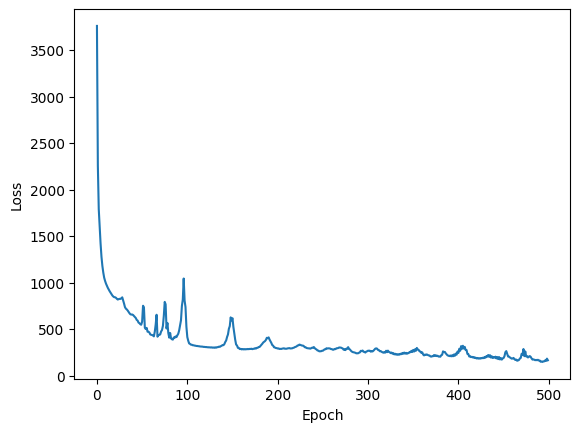

In [18]:
# model training
train(rnn_model, epochs=500)
train(transformer_model, epochs=500)

In [19]:
# evaluate model on the test set
criterion = nn.MSELoss()
rnn_predictions, rnn_groundtruth = test(rnn_model, test_loader, criterion)
transformer_predictions, transformer_groundtruth = test(transformer_model, test_loader, criterion)

Evaluation: 925.0163964636532
Evaluation: 1496.7419239091284


RNN Model Plot:


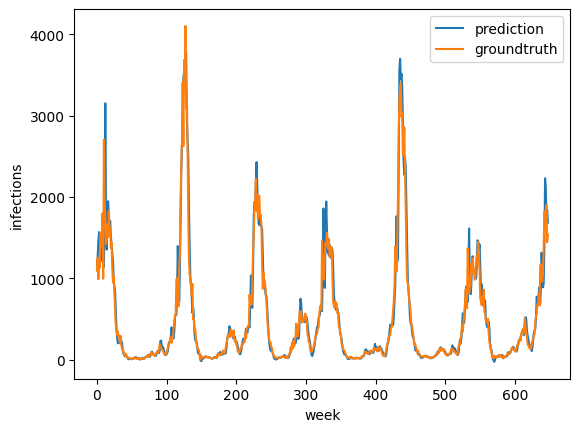

Transformer Model Plot:


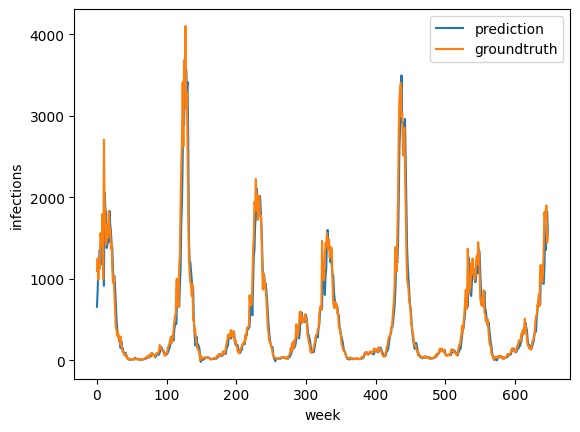

(tensor([ 6.5866e+02,  8.4483e+02,  1.1281e+03,  1.2147e+03,  1.3563e+03,
          1.1725e+03,  1.4846e+03,  1.5700e+03,  1.4291e+03,  1.5894e+03,
          9.1452e+02,  2.0577e+03,  1.8716e+03,  1.8023e+03,  1.3793e+03,
          1.4195e+03,  1.5438e+03,  1.4502e+03,  1.8338e+03,  1.6684e+03,
          1.6005e+03,  1.4292e+03,  1.3852e+03,  1.1004e+03,  9.9140e+02,
          1.0348e+03,  9.0362e+02,  7.1487e+02,  5.1810e+02,  3.9649e+02,
          2.9823e+02,  3.0892e+02,  2.3181e+02,  2.2699e+02,  1.5080e+02,
          2.3623e+02,  1.3351e+02,  1.5054e+02,  9.6278e+01,  8.8988e+01,
          9.1488e+01,  9.3886e+01,  6.8908e+01,  5.2594e+01,  2.4676e+01,
          1.3643e+01,  1.6280e+01,  5.6011e+00,  1.1400e+01,  9.3155e+00,
          1.1954e+01,  1.1392e+01,  1.1817e+01,  1.7127e+01,  1.2259e+01,
          3.4074e+01,  2.3246e+01,  1.5269e+01,  1.7394e+01,  1.4219e+01,
          1.7623e+01,  1.2864e+01,  5.1600e+00,  8.1407e+00,  1.0945e+01,
          1.3152e+01,  1.1622e+01,  1.

In [32]:
# visualize the result
print("RNN Model Plot:")
plot(rnn_model, test_loader)
print("Transformer Model Plot:")
plot(transformer_model, test_loader)